In [1]:
import os
import sys

sys.path.append(os.path.abspath("../src"))

import pandas as pd

from utils import dataset_info
from eda import perform_eda
from preprocessing import preprocess_data
from feature_selection import select_features
from classification import train_classification
from metrics import classification_metrics

In [2]:
df = pd.read_csv(
    "../datasets/raw/iris.csv",
    header=None
)

df.columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

In [3]:
dataset_info(df)

DATASET INFORMATION

Shape : (150, 5)

Columns
['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']

Data Types
SepalLength    float64
SepalWidth     float64
PetalLength    float64
PetalWidth     float64
Species         object
dtype: object

Missing Values
SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64

Duplicate Rows
3

Summary Statistics
        SepalLength  SepalWidth  PetalLength  PetalWidth      Species
count    150.000000  150.000000   150.000000  150.000000          150
unique          NaN         NaN          NaN         NaN            3
top             NaN         NaN          NaN         NaN  Iris-setosa
freq            NaN         NaN          NaN         NaN           50
mean       5.843333    3.054000     3.758667    1.198667          NaN
std        0.828066    0.433594     1.764420    0.763161          NaN
min        4.300000    2.000000     1.000000    0.100000          NaN
25%        5.100000    2.80000

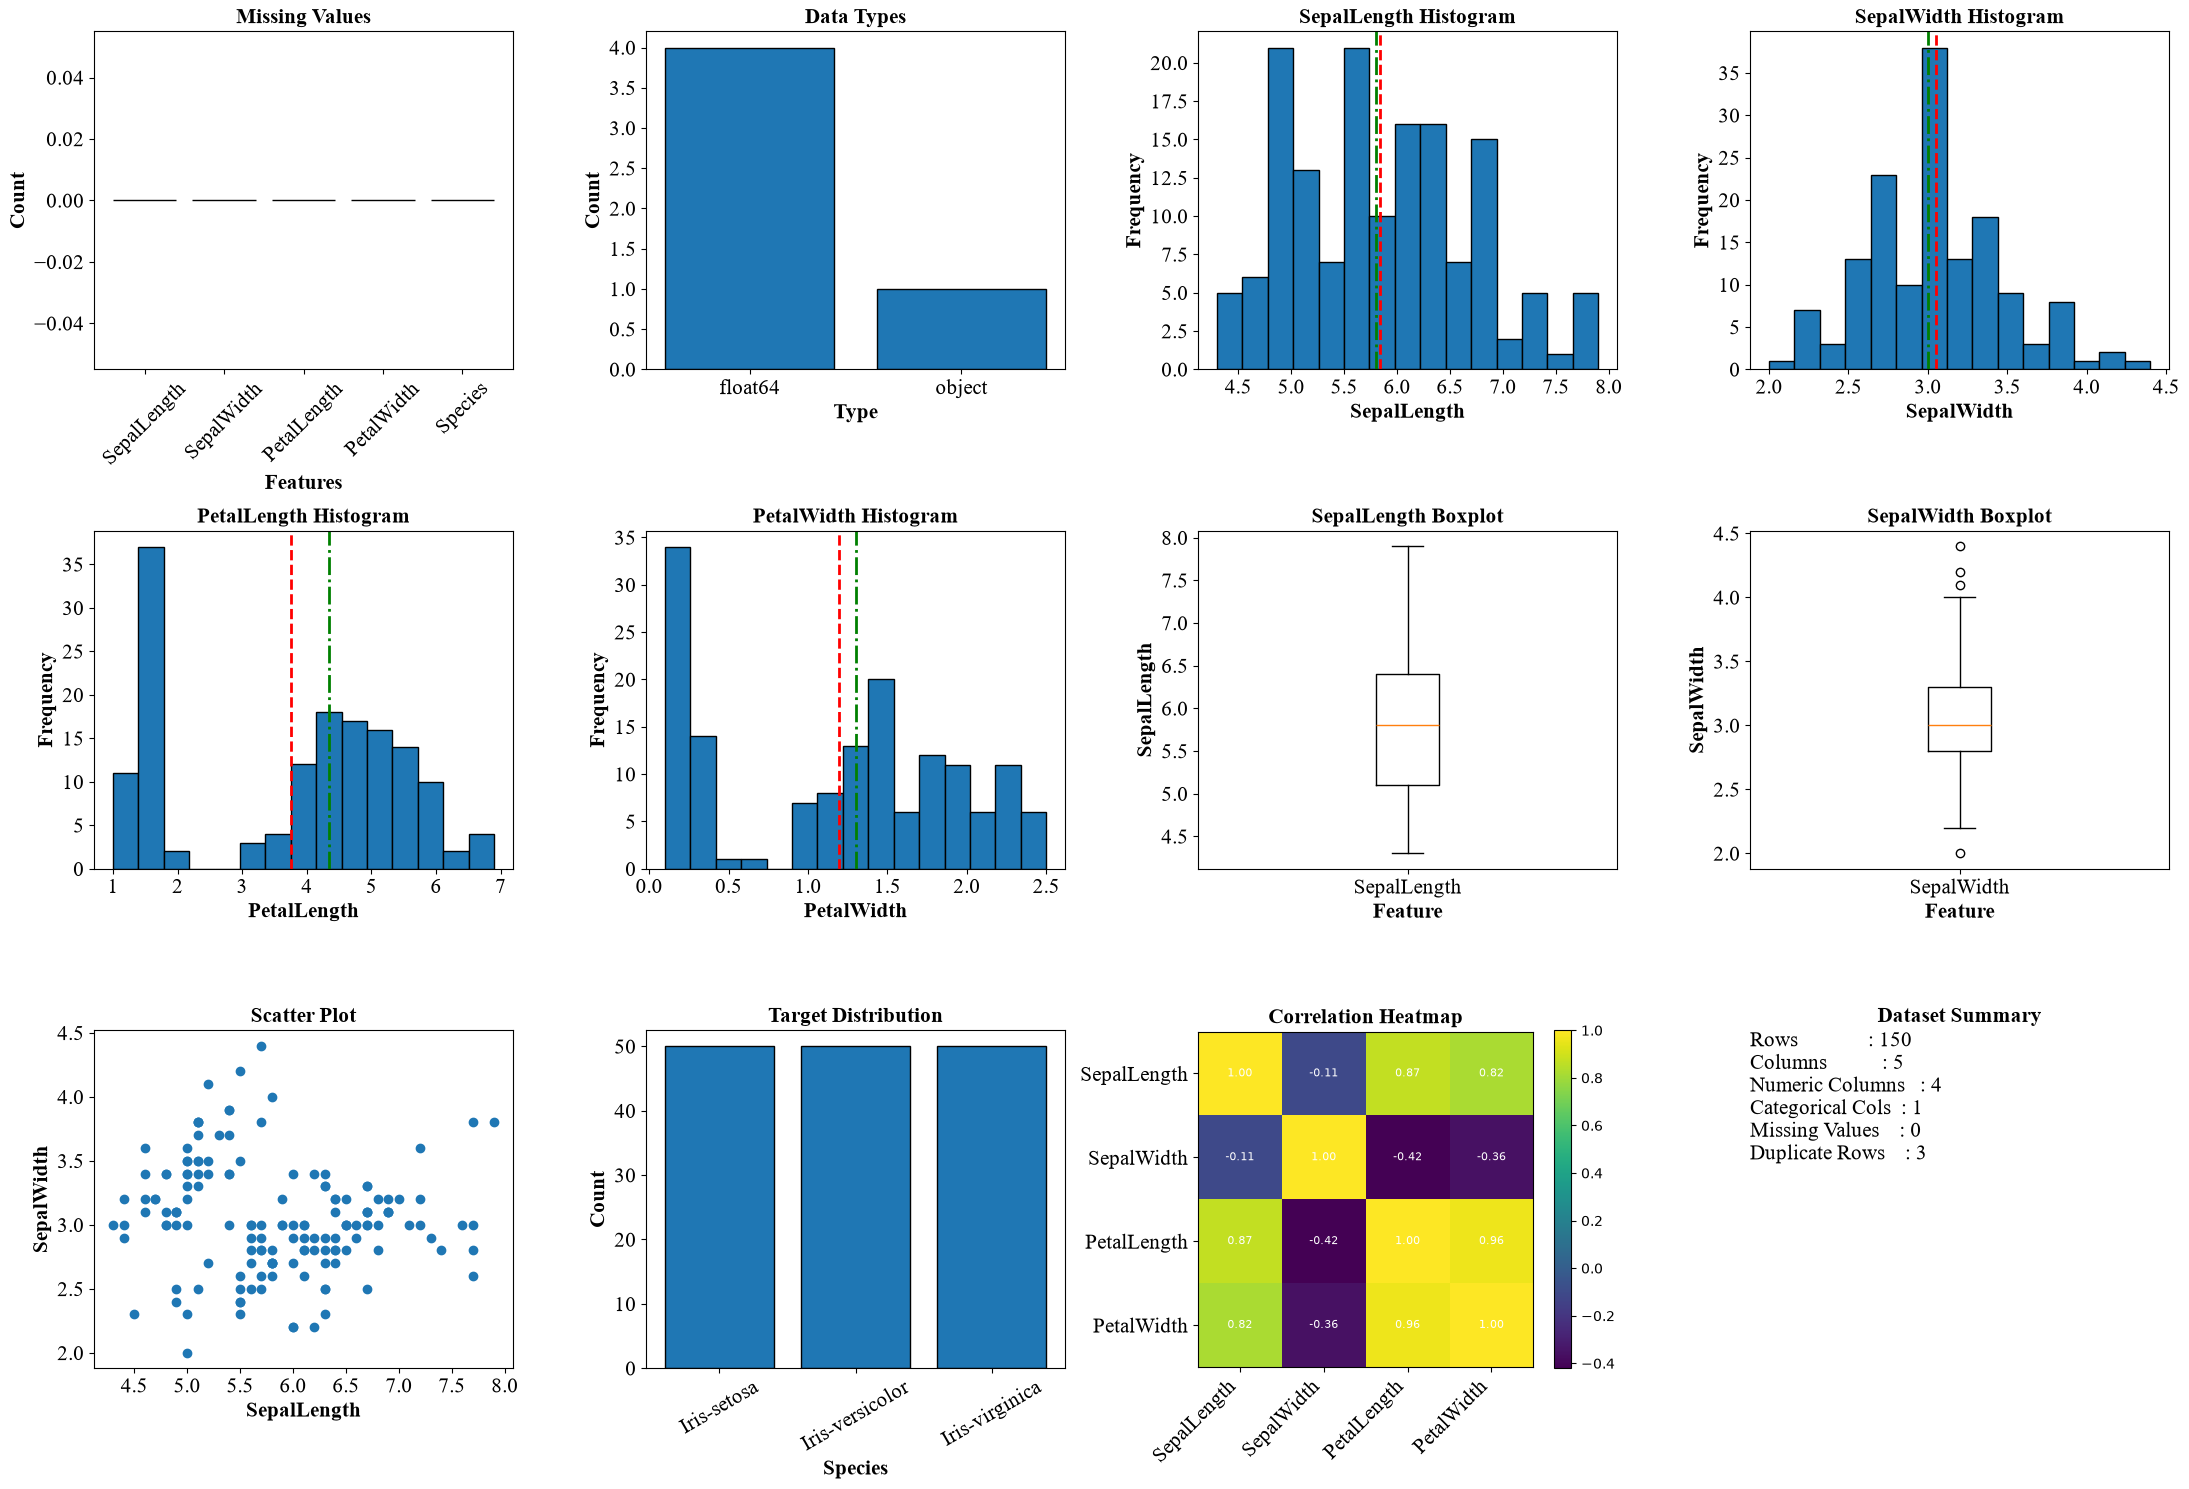

In [4]:
summary = perform_eda(
    df=df,
    target_column="Species",
    save=True,
    filename="iris_eda"
)

In [5]:
X_train, X_test, y_train, y_test, scaler, encoders = preprocess_data(
    df=df,
    target_column="Species",
    drop_cols=None,
    encode=True,
    scale=True,
    stratify=True,
    test_size=0.2,
    random_state=42
)

In [6]:
X_train, X_test, selector = select_features(
    X_train,
    X_test,
    y_train,
    method="anova",
    k="all"
)

RANDOM_FOREST

========== Classification Metrics ==========

Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1 Score : 0.9666

Confusion Matrix

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

ROC AUC : 0.9900


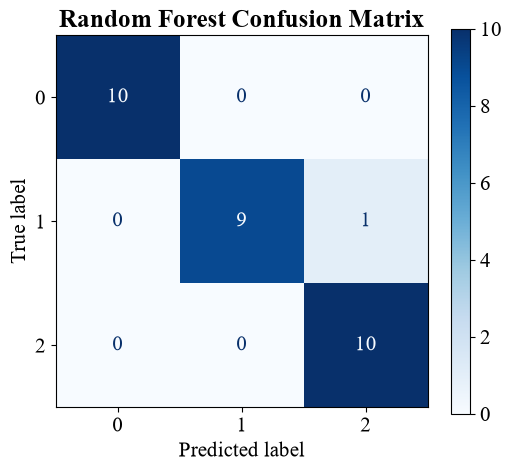

DECISION_TREE

========== Classification Metrics ==========

Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

Confusion Matrix

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

ROC AUC : 0.9500


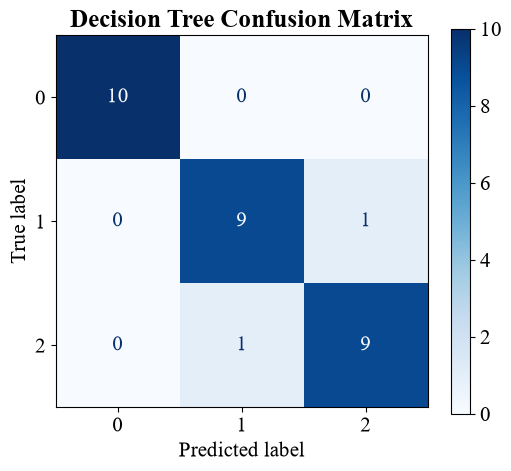

KNN

========== Classification Metrics ==========

Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327

Confusion Matrix

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

ROC AUC : 0.9933


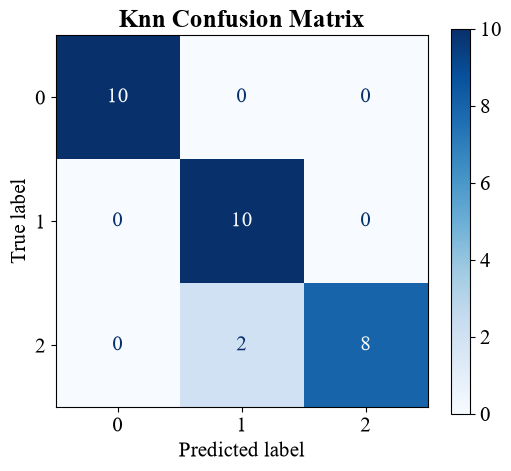

SVM

========== Classification Metrics ==========

Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1 Score : 0.9666

Confusion Matrix

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

ROC AUC : 0.9967


C:\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


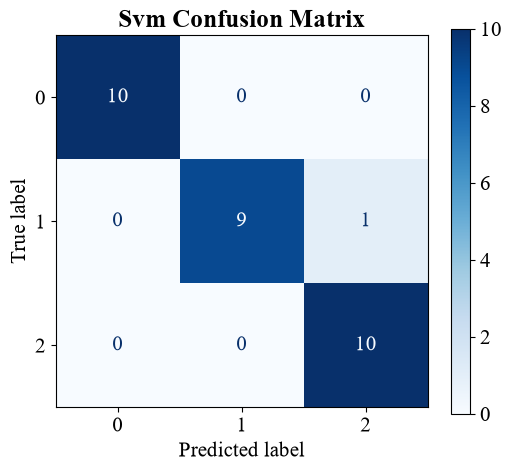

In [7]:
algorithms = [
    "random_forest",
    "decision_tree",
    "knn",
    "svm"
]

for algo in algorithms:

    print("="*70)
    print(algo.upper())
    print("="*70)

    model = train_classification(
        X_train,
        y_train,
        algorithm=algo
    )

    classification_metrics(
        model,
        X_test,
        y_test,
        model_name=algo
    )